In [1]:
import numpy as np
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted
import dask.array as da
import dask_image.imread
import cv2
from tifffile import TiffWriter
import nibabel as nib
import skimage.transform
import tifffile

In [2]:
in_dir = '/Users/KARATB01/bigpurple_data/micmac'

ref = nib.load(f'{in_dir}/histo_volumes/MicrogliaBlock200um_no-optical.nii')
ref_affine = ref.affine
ref_hdr = ref.header
ref_dat = ref.get_fdata()


In [3]:
ref_affine

array([[  0.2       ,   0.        ,   0.        , -31.65999985],
       [  0.        ,   0.43742701,   0.        , -38.45399857],
       [  0.        ,   0.        ,   0.2       , -30.40999985],
       [  0.        ,   0.        ,   0.        ,   1.        ]])

In [9]:
ref_dat.shape

(340, 191, 281)

In [66]:
img_hold = np.empty((340,281,191))
arr_num = np.linspace(170,1,170).astype(int)

for ii in range(170):

    img_hold[:,:,ii+10] = np.squeeze(nib.load(f'{in_dir}/downsampled_image_test/temp_slices_resampled/41759_G_{arr_num[ii]:03d}.nii').get_fdata()) # doing +10 because want image centered with 170 slices in a box of 191 depth


In [74]:
img_swap = np.swapaxes(img_hold,1,2)

In [ ]:
from scipy import ndimage

smoothed_img_swap = ndimage.gaussian_filter(img_swap[:,100,:], sigma=1)


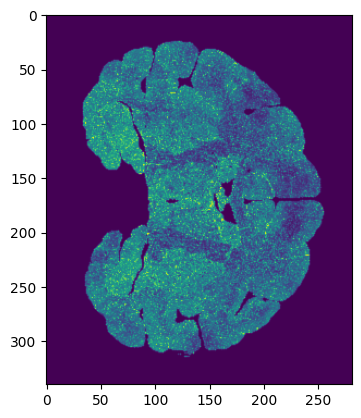

In [ ]:
plt.imshow(smoothed_img_swap[:,:])

In [ ]:
#smooth_test = np.squeeze(nib.load(f'{in_dir}/microglia_2um_nissl_aligned_images/41759_G_110.mnc').get_fdata()) # doing +10 because want image centered with 170 slices in a box of 191 depth


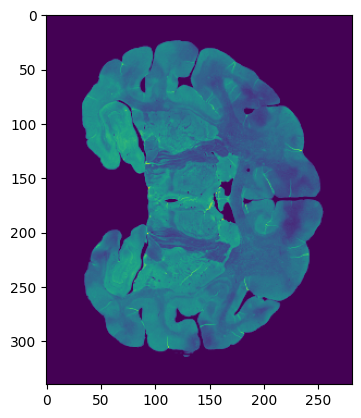

In [101]:
plt.imshow(ref_dat[:,100,:])

In [78]:
img_save = nib.Nifti1Image(img_swap,ref_affine,ref_hdr)
nib.save(img_save,f'{in_dir}/downsampled_image_test/microglia_200um_manual_nii.nii.gz')

In [4]:
test1 = np.squeeze(nib.load(f'{in_dir}/microglia_2um_nissl_aligned_images/41759_G_070.mnc').get_fdata()) # doing +10 because want image centered with 170 slices in a box of 191 depth
test2 = np.squeeze(nib.load(f'{in_dir}/microglia_2um_nissl_aligned_images/41759_G_073.mnc').get_fdata()) # doing +10 because want image centered with 170 slices in a box of 191 depth


In [5]:
test1.shape

(28100, 34000)

In [12]:
from scipy import ndimage

seg_image1 = ndimage.gaussian_filter(test1, sigma=10) # smooth
seg_image2 = ndimage.gaussian_filter(test2, sigma=10) # smooth

seg_down1 = cv2.resize(seg_image1.astype(np.uint8), (340, 281), interpolation=cv2.INTER_LINEAR)
seg_down2 = cv2.resize(seg_image2.astype(np.uint8), (340, 281), interpolation=cv2.INTER_LINEAR)

seg_down1 = np.swapaxes(seg_down1,0,1)
seg_down2 = np.swapaxes(seg_down2,0,1)


In [13]:
img_hold = np.empty((seg_down1.shape[0],seg_down1.shape[1],191))

img_hold[:,:,110] = seg_down1
img_hold[:,:,113] = seg_down1


In [14]:
img_swap = np.swapaxes(img_hold,1,2)

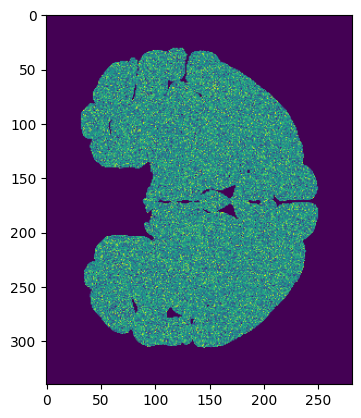

In [15]:
plt.imshow(img_swap[:,110,:])

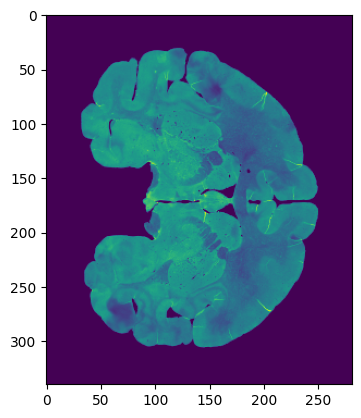

In [8]:
plt.imshow(ref_dat[:,110,:])

In [3]:
arr_num = np.linspace(170,1,170).astype(int) # histo files need to be put into array in reverse order

in_dir = '/Users/KARATB01/bigpurple_data/micmac'

In [ ]:
for aa in range(len(arr_num)):
        
    seg_down = np.squeeze(nib.load(f'{in_dir}/downsampled_image_test/temp_slices_resampled_nii/41759_G_{arr_num[aa]:03d}.nii.gz').get_fdata()) # start with slice 170

    if aa == 0:
        img_hold = np.empty((seg_down.shape[0],191,seg_down.shape[1]))


    img_hold[:,aa+10,:] = seg_down



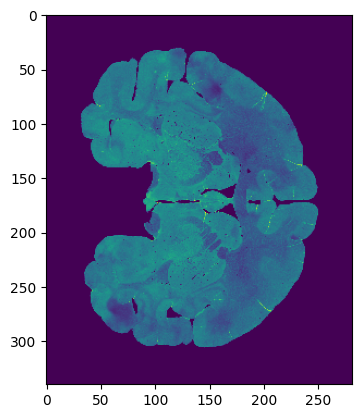

In [5]:
plt.imshow(img_hold[:,110,:])

In [6]:
img_save = nib.Nifti1Image(img_hold, ref_affine, ref_hdr)
nib.save(img_save, f'{in_dir}/downsampled_image_test/microglia_200um_image_smoothed_downsampled_image.nii.gz')

## Consider after combining the 200um image, to smooth once more 3D

In [38]:
for aa in range(len(arr_num)):
        
    seg_down = np.squeeze(nib.load(f'{in_dir}/microglia_200um_nissl_aligned_segmentations/temp_slices_resampled_nii_segmentations_MISSING/41759_G_{arr_num[aa]:03d}.nii.gz').get_fdata()) # start with slice 170

    if aa == 0:
        img_hold = np.empty((seg_down.shape[0],191,seg_down.shape[1]))


    img_hold[:,aa+10,:] = seg_down


In [ ]:
# SAVE NO 3D SMOOTHING
img_save = nib.Nifti1Image(img_hold, ref_affine, ref_hdr)
nib.save(img_save, f'{in_dir}/microglia_200um_nissl_aligned_segmentations/microglia_200um_image_smoothed_downsampled_segmentation.nii.gz')

In [40]:
img_hold.shape

(340, 191, 281)

In [73]:
## Trying also to smooth in 3D

seg_image_3D_smooth = ndimage.gaussian_filter(img_hold, sigma=1) # smooth


In [74]:
# SAVE 3D SMOOTHING
img_save = nib.Nifti1Image(seg_image_3D_smooth, ref_affine, ref_hdr)
nib.save(img_save, f'{in_dir}/microglia_200um_nissl_aligned_segmentations/microglia_200um_image_smoothed_with_3D_filter_downsampled_segmentation.nii.gz')

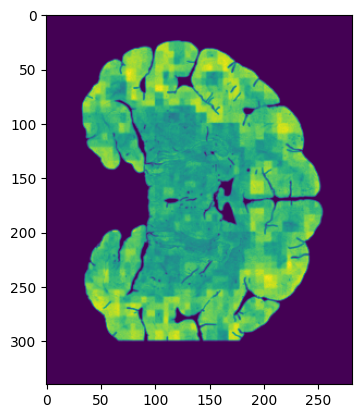

In [69]:
plt.imshow(img_hold[:,100,:])

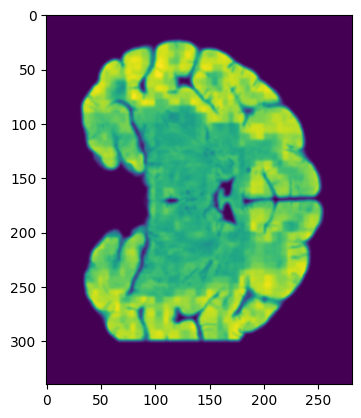

In [70]:
plt.imshow(seg_image_3D_smooth[:,100,:])

In [6]:
img_save = nib.Nifti1Image(img_hold, ref_affine, ref_hdr)
nib.save(img_save, f'{in_dir}/microglia_200um_nissl_aligned_segmentations/microglia_200um_image_smoothed_downsampled_segmentation.nii.gz')

## Plotting sigma 25 vs sigma 50

In [14]:
seg_down_25 = np.squeeze(nib.load(f'{in_dir}/microglia_200um_nissl_aligned_segmentations/temp_slices_resampled_nii_segmentations/41759_G_110.nii.gz').get_fdata()) # start with slice 170
seg_down_50 = np.squeeze(nib.load(f'{in_dir}/microglia_200um_nissl_aligned_segmentations/temp_slices_resampled_nii_segmentations_MISSING/41759_G_110.nii.gz').get_fdata()) # start with slice 170


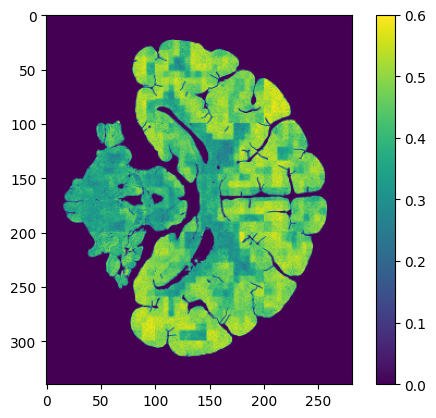

In [30]:
plt.imshow(seg_down_25)
plt.colorbar()
plt.clim(0,0.6)

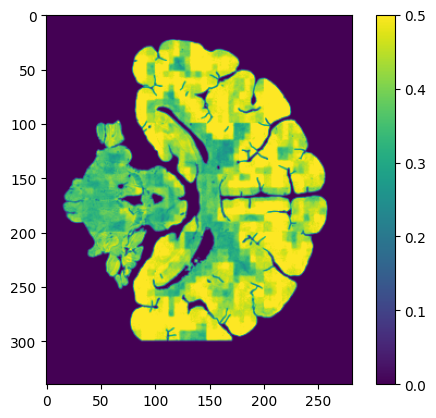

In [16]:
plt.imshow(seg_down_50)
plt.colorbar()
plt.clim(0,0.5)

In [17]:
seg_image_recon = np.squeeze(tifffile.imread(f'{in_dir}/microglia_2um_nissl_aligned_low_high_unet_reconstructed_segmentations/41759_G_110.tiff')) # start with slice 170


In [36]:
from scipy import ndimage

seg_image = ndimage.gaussian_filter(seg_image_recon.astype(np.float64), sigma=300) # smooth

scale_factor = 2 / 200 
new_height = int(seg_image.shape[1] * scale_factor)
new_width = int(seg_image.shape[0] * scale_factor)

seg_down = cv2.resize(seg_image, (new_height, new_width), interpolation=cv2.INTER_LINEAR)
seg_down = np.swapaxes(seg_down,0,1)

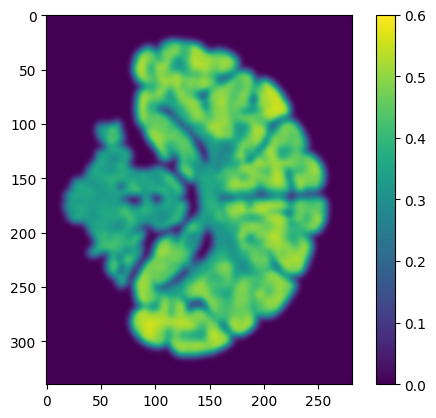

In [37]:
#SIGMA 300
plt.imshow(seg_down)
plt.colorbar()
plt.clim(0,0.6)

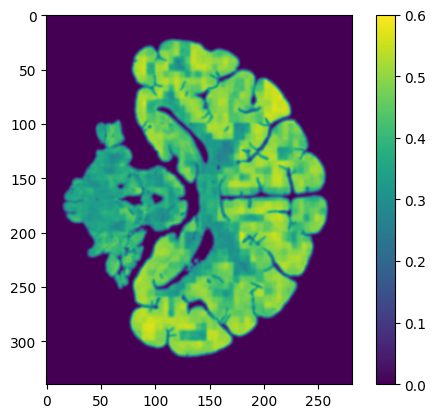

In [35]:
#SIGMA 100
plt.imshow(seg_down)
plt.colorbar()
plt.clim(0,0.6)

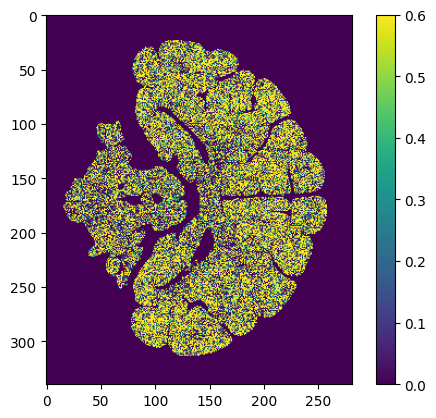

In [33]:
#SIGMA 1
plt.imshow(seg_down)
plt.colorbar()
plt.clim(0,0.6)

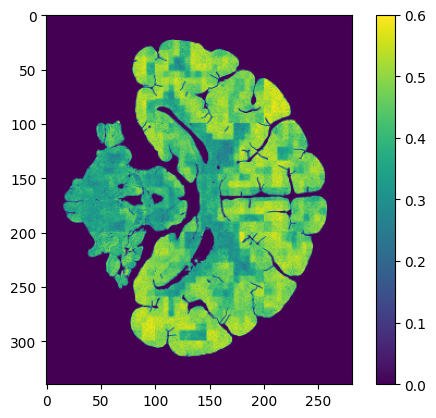

In [ ]:
#SIGMA 25
plt.imshow(seg_down)
plt.colorbar()
plt.clim(0,0.6)

## Testing slice reconstruction